# 🏠 House Price Prediction

## Machine Learning Regression Project

**Prepared By:** Harshit Gautam  
**Email:** harshitgautam8118@gmail.com

---

### Objective:
Build a regression model to predict house prices using property features like area, bedrooms, bathrooms, location, and amenities.

### Tools Used:
Python | Pandas | Scikit-learn | Matplotlib | Seaborn

# 1. Data Loading & Exploration

Import libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully")

Libraries imported successfully


Load dataset

In [3]:
df = pd.read_csv("Housing.csv")

df.head(10)

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
5,10850000,7500,3,3,1,yes,no,yes,no,yes,2,yes,semi-furnished
6,10150000,8580,4,3,4,yes,no,no,no,yes,2,yes,semi-furnished
7,10150000,16200,5,3,2,yes,no,no,no,no,0,no,unfurnished
8,9870000,8100,4,1,2,yes,yes,yes,no,yes,2,yes,furnished
9,9800000,5750,3,2,4,yes,yes,no,no,yes,1,yes,unfurnished


Shape

In [4]:
df.shape

(545, 13)

Columns

In [5]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

Info

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


# 2. Data Cleaning & Preprocessing

Missing values

In [7]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicates

In [8]:
df.duplicated().sum()

np.int64(0)

Remove duplicates

In [9]:
df = df.drop_duplicates()

df.shape

(545, 13)

Convert yes/no

In [10]:
yes_no_columns = [
    'mainroad',
    'guestroom',
    'basement',
    'hotwaterheating',
    'airconditioning',
    'prefarea'
]

for col in yes_no_columns:
    df[col] = df[col].map({'yes':1, 'no':0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,furnished
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,furnished
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,semi-furnished
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,furnished
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,furnished


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 14 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   price                            545 non-null    int64
 1   area                             545 non-null    int64
 2   bedrooms                         545 non-null    int64
 3   bathrooms                        545 non-null    int64
 4   stories                          545 non-null    int64
 5   mainroad                         545 non-null    int64
 6   guestroom                        545 non-null    int64
 7   basement                         545 non-null    int64
 8   hotwaterheating                  545 non-null    int64
 9   airconditioning                  545 non-null    int64
 10  parking                          545 non-null    int64
 11  prefarea                         545 non-null    int64
 12  furnishingstatus_semi-furnished  545 non-null    b

# 3. Model Building & Evaluation

Split Data

In [14]:
X = df.drop('price', axis=1)
y = df['price']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (545, 13)
Target shape: (545,)


Train test split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (436, 13)
Testing data: (109, 13)


## Linear Regression Model

Train Linear Regression

In [16]:
lr_model = LinearRegression()ine

lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)

print("Linear Regression trained")

Linear Regression trained


Linear Evaluation

In [17]:
lr_mae = mean_absolute_error(y_test, lr_pred)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

lr_r2 = r2_score(y_test, lr_pred)


print("Linear Regression Results")
print("-------------------------")
print("MAE:", lr_mae)
print("RMSE:", lr_rmse)
print("R2 Score:", lr_r2)

Linear Regression Results
-------------------------
MAE: 970043.4039201637
RMSE: 1324506.9600914384
R2 Score: 0.6529242642153186


## Random Forest Regressor

Train Random Forest

In [18]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

print("Random Forest trained")

Random Forest trained


Random Forest Evaluation

In [19]:
rf_mae = mean_absolute_error(y_test, rf_pred)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

rf_r2 = r2_score(y_test, rf_pred)


print("Random Forest Results")
print("---------------------")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R2 Score:", rf_r2)

Random Forest Results
---------------------
MAE: 1022560.0527522935
RMSE: 1401496.8425384816
R2 Score: 0.6114024924156645


# 4. Data Visualization

Distribution of House Prices

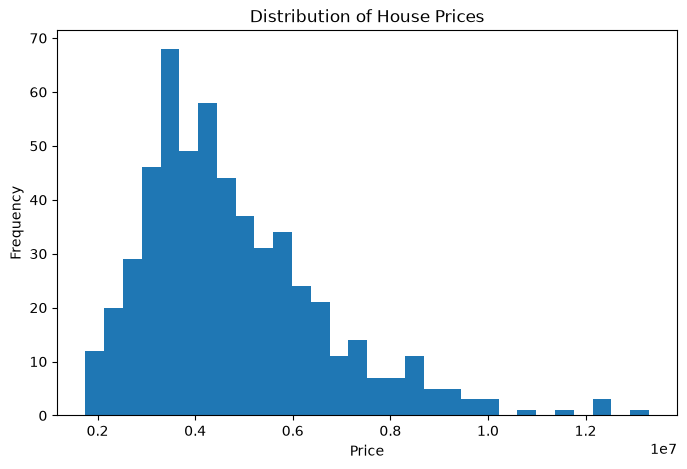

In [20]:
plt.figure(figsize=(8,5))

plt.hist(df['price'], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")

plt.savefig("charts/price_distribution.png")

plt.show()

Feature Correlation Heatmap

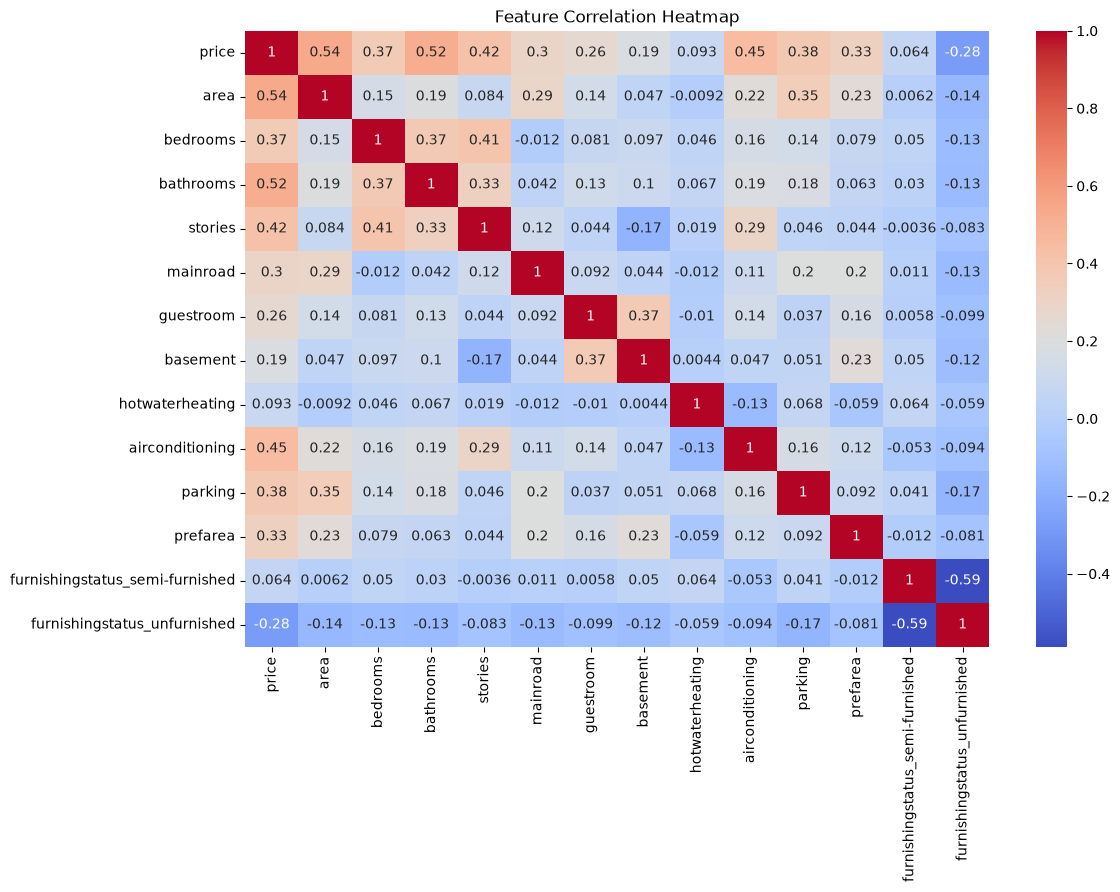

In [21]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.savefig("charts/correlation_heatmap.png")

plt.show()

Actual vs Predicted House Price

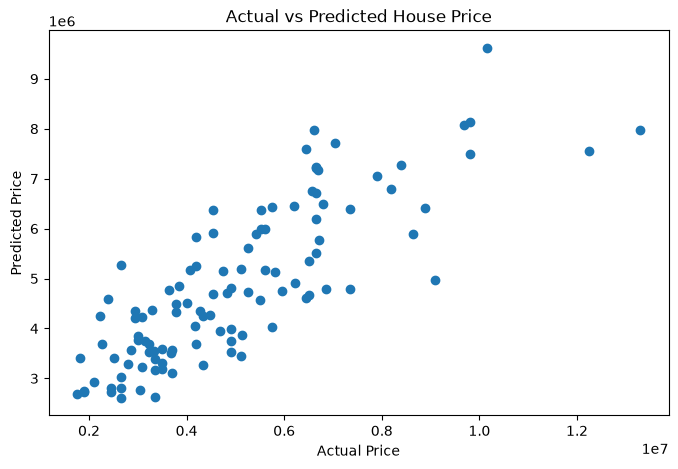

In [22]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    lr_pred
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Price")

plt.savefig("charts/actual_vs_predicted.png")

plt.show()

## Feature Importance Analysis

In [23]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,area,0.467917
2,bathrooms,0.151526
8,airconditioning,0.062718
9,parking,0.057820
3,stories,0.057137
1,bedrooms,0.048608
12,furnishingstatus_unfurnished,0.034998
6,basement,0.030804
10,prefarea,0.030519
7,hotwaterheating,0.017255


Feature importance chart

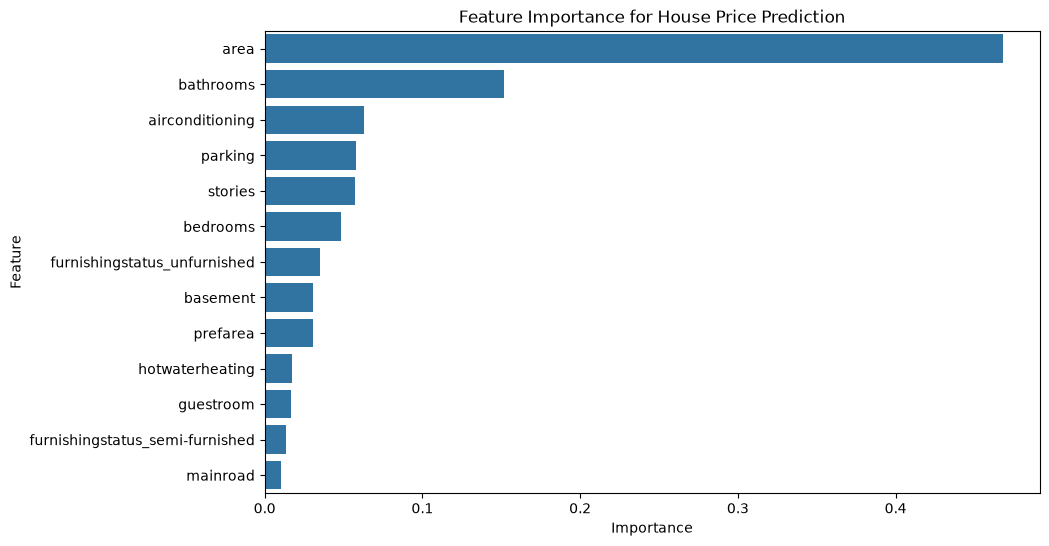

In [24]:
plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance for House Price Prediction")

plt.savefig("charts/feature_importance.png")

plt.show()

## Insights & Summary

The analysis shows that house price is mainly influenced by property size, number of bathrooms, 
number of bedrooms, and location-related features such as preferred area. The Linear Regression 
model achieved an R² score of approximately 65%, meaning it explains a good portion of price 
variation. The model can provide a reasonable estimate of house prices but may have some error 
because real estate prices depend on many external factors. It was interesting to observe that 
certain location features had a strong impact on prices. A real estate business can use this model 
to support pricing decisions and provide data-driven property valuations.

In [1]:
from docx import Document

doc = Document()

doc.add_heading("House Price Prediction - Project Summary", level=1)

doc.add_paragraph(
"""
Project Objective:
The aim of this project was to build a machine learning model to predict house prices
based on property features such as area, bedrooms, bathrooms, location, and amenities.
"""

)

doc.add_heading("Data Analysis & Cleaning", level=2)

doc.add_paragraph(
"""
The dataset was loaded using Pandas and explored to understand its structure.
Missing values were checked and duplicate records were removed.
Categorical features such as yes/no fields and furnishing status were converted into
numeric form for machine learning.
"""
)

doc.add_heading("Model Performance", level=2)

doc.add_paragraph(
"""
Two regression models were trained:

Linear Regression:
MAE: 970043
RMSE: 1324507
R2 Score: 0.65

Random Forest Regressor:
MAE: 1022560
RMSE: 1401497
R2 Score: 0.61

Linear Regression performed better on this dataset.
"""
)

doc.add_heading("Key Insights", level=2)

doc.add_paragraph(
"""
Feature importance analysis showed that area is the most important factor influencing
house prices, followed by bathrooms, air conditioning, parking facilities, and number
of stories.

The model can help real estate businesses estimate property values and make
data-driven pricing decisions.
"""
)

doc.save("summary.docx")

print("Summary document created successfully")

Summary document created successfully


# Conclusion

The House Price Prediction project successfully analyzed housing data,
trained regression models, evaluated performance, and identified important
features affecting house prices.